In [5]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-darkgrid")

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)
DATA_PATH = Path("../data/creditcard.csv")

print("All imports OK ✓")

C:\Users\bomma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports OK ✓


In [6]:
# ── Cell 2: Load + Inspect ───────────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\bomma\Downloads\Projects\fraud-sentinel\creditcard.csv")

print(f"Shape: {df.shape}")
print(f"\nDtype summary:\n{df.dtypes.value_counts()}")
print(f"\nNull values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nAmount stats:\n{df['Amount'].describe()}")

Shape: (284807, 31)

Dtype summary:
float64    30
int64       1
Name: count, dtype: int64

Null values: 0
Duplicate rows: 1081

Amount stats:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


Legit:  284,315  (99.83%)
Fraud:  492  (0.1727%)


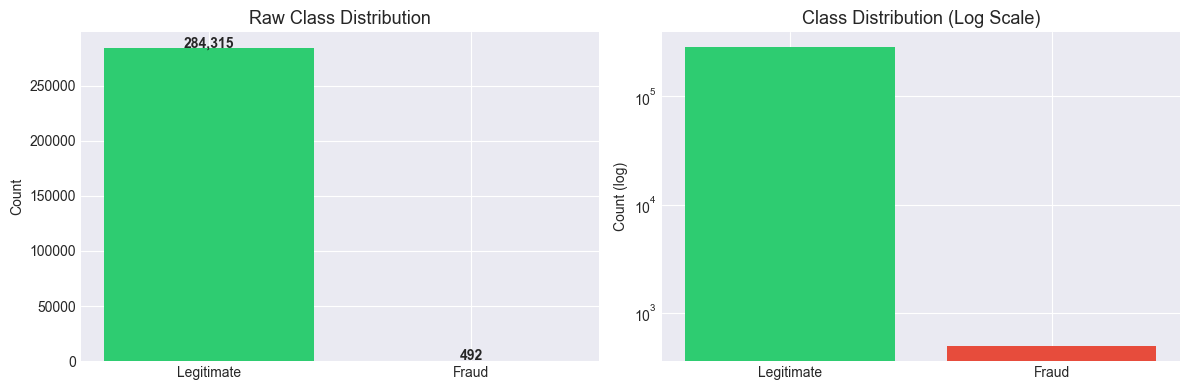

In [7]:
# ── Cell 3: Class Distribution ───────────────────────────────────────────────
class_counts = df['Class'].value_counts()
fraud_rate = class_counts[1] / len(df) * 100

print(f"Legit:  {class_counts[0]:,}  ({100-fraud_rate:.2f}%)")
print(f"Fraud:  {class_counts[1]:,}  ({fraud_rate:.4f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraud'], class_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Raw Class Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Log scale — shows imbalance clearly
axes[1].bar(['Legitimate', 'Fraud'], class_counts.values, color=['#2ecc71', '#e74c3c'], log=True)
axes[1].set_title('Class Distribution (Log Scale)', fontsize=13)
axes[1].set_ylabel('Count (log)')

plt.tight_layout()
plt.savefig(MODELS_DIR / "class_distribution.png", dpi=120)
plt.show()

# ─── CRISP-ML(Q) Note ────────────────────────────────────────────────────────
# WHY this matters:
# 0.17% fraud rate → if model predicts ALL LEGITIMATE → 99.83% accuracy.
# Accuracy is useless here. We use F1 on fraud class + ROC-AUC.
# A model that catches 0 frauds is worse than useless for a bank.

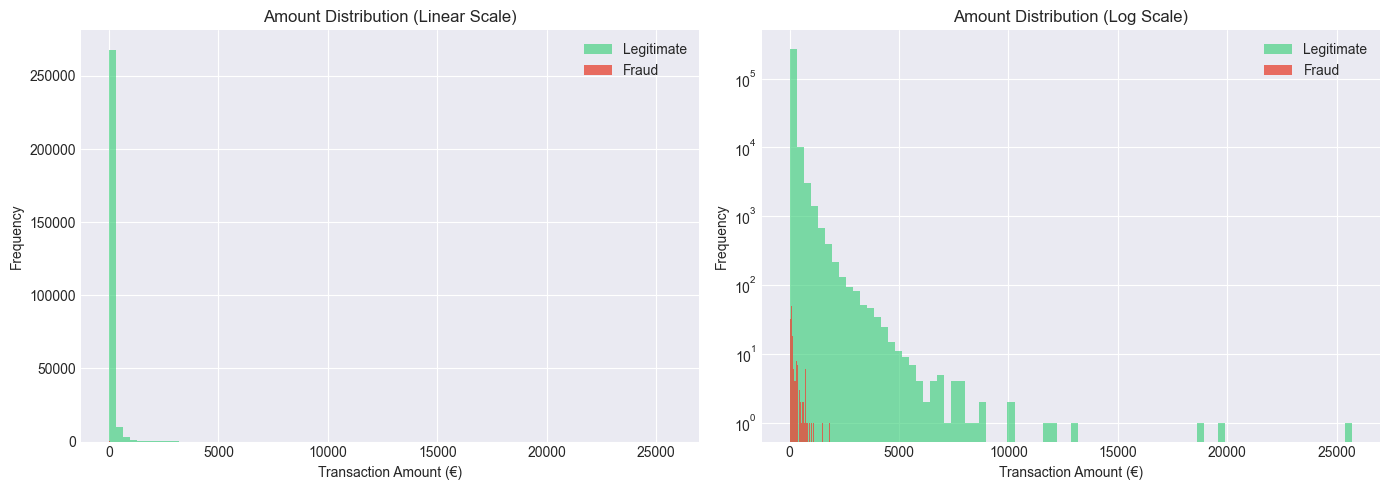

Fraud median amount:  €9.25
Legit median amount:  €22.00


In [8]:
# ── Cell 4: Amount Distribution by Class ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, log in zip(axes, [False, True]):
    df[df.Class == 0]['Amount'].hist(bins=80, alpha=0.6, label='Legitimate', color='#2ecc71', ax=ax)
    df[df.Class == 1]['Amount'].hist(bins=80, alpha=0.8, label='Fraud', color='#e74c3c', ax=ax)
    ax.set_xlabel('Transaction Amount (€)')
    ax.set_ylabel('Frequency')
    ax.legend()
    if log:
        ax.set_yscale('log')
        ax.set_title('Amount Distribution (Log Scale)')
    else:
        ax.set_title('Amount Distribution (Linear Scale)')

plt.tight_layout()
plt.savefig(MODELS_DIR / "amount_distribution.png", dpi=120)
plt.show()

print(f"Fraud median amount:  €{df[df.Class==1]['Amount'].median():.2f}")
print(f"Legit median amount:  €{df[df.Class==0]['Amount'].median():.2f}")

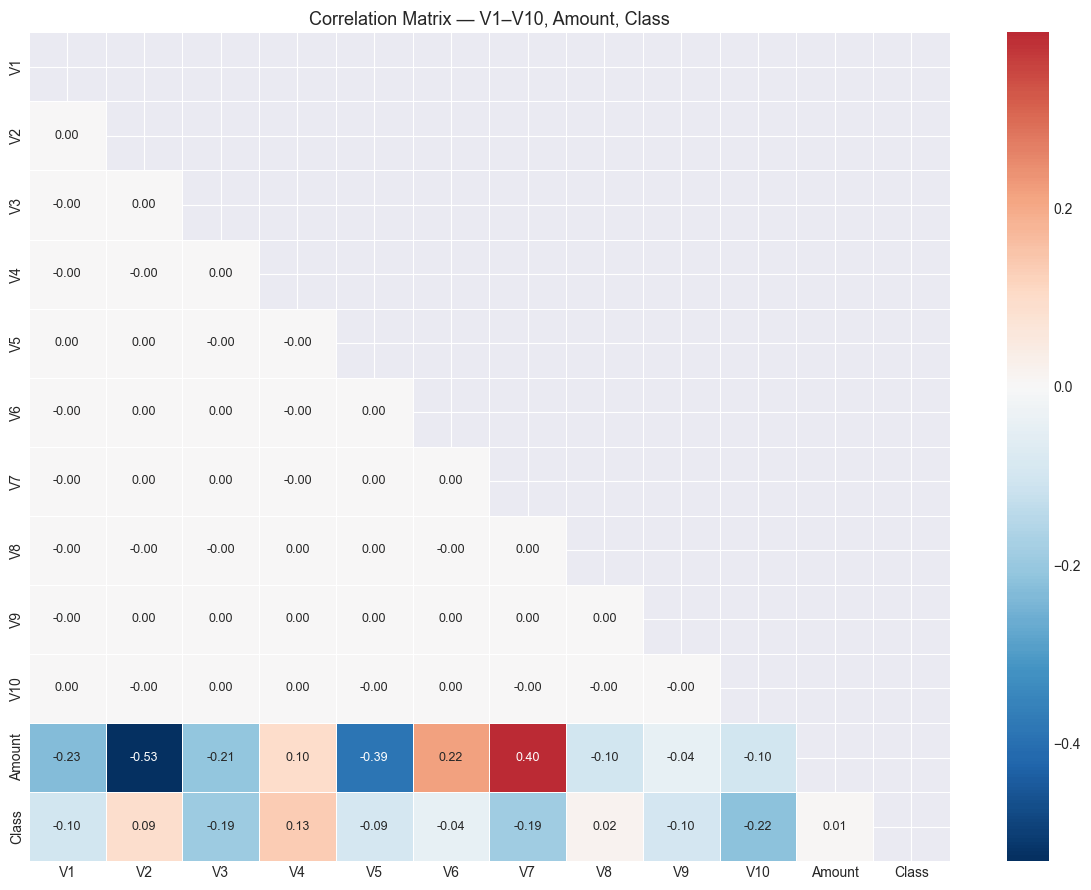

Top 10 features by |correlation| with fraud class:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485


In [9]:
# ── Cell 5: Correlation Heatmap (V1–V10 + Amount + Class) ────────────────────
corr_cols = [f'V{i}' for i in range(1, 11)] + ['Amount', 'Class']
corr = df[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title('Correlation Matrix — V1–V10, Amount, Class', fontsize=13)
plt.tight_layout()
plt.savefig(MODELS_DIR / "correlation_heatmap.png", dpi=120)
plt.show()

# Which V features correlate most with fraud?
class_corr = df[[f'V{i}' for i in range(1, 29)] + ['Amount']].corrwith(df['Class']).abs()
top_corr = class_corr.sort_values(ascending=False).head(10)
print("Top 10 features by |correlation| with fraud class:")
print(top_corr.to_string())

In [10]:
# ── Cell 6: Feature Engineering + Train/Val/Test Split ───────────────────────
# Drop duplicates after EDA confirms they exist
df = df.drop_duplicates()
print(f"After dedup: {df.shape}")

# Feature matrix + target
X = df.drop('Class', axis=1)  # Time, V1-V28, Amount → 30 features
y = df['Class']

# Stratified split: 80% train | 10% val | 10% test
# WHY stratified? Preserves 0.17% fraud rate in every split.
# WHY holdout test set? Gives unbiased final evaluation AFTER all tuning.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.111, random_state=42, stratify=y_temp
    # 0.111 of 0.90 = 0.10 of total → 80/10/10
)

print(f"Train: {X_train.shape} | Fraud: {y_train.sum()}")
print(f"Val:   {X_val.shape}   | Fraud: {y_val.sum()}")
print(f"Test:  {X_test.shape}  | Fraud: {y_test.sum()}")

After dedup: (283726, 31)
Train: (227008, 30) | Fraud: 379
Val:   (28345, 30)   | Fraud: 47
Test:  (28373, 30)  | Fraud: 47


In [11]:
# ── Cell 7: SMOTE — Training Set Only ────────────────────────────────────────
# WHY SMOTE on training only?
# SMOTE creates SYNTHETIC samples to balance the training distribution.
# If we apply it to val/test, we're evaluating on fake data → inflated metrics.
# Val and test must reflect REAL-WORLD distribution (0.17% fraud).
#
# How SMOTE works:
#   For each minority (fraud) sample, it finds K nearest fraud neighbors,
#   then creates new points along the line segment between them.
#   Result: fraud class goes from 0.17% → 50% in training data.

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE:  {pd.Series(y_train_bal).value_counts().to_dict()}")
print(f"Training set size after SMOTE: {X_train_bal.shape}")

Before SMOTE: {0: 226629, 1: 379}
After SMOTE:  {0: 226629, 1: 226629}
Training set size after SMOTE: (453258, 30)


In [12]:
# ── Cell 8: XGBoost Baseline (before tuning) ─────────────────────────────────
baseline = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',   # faster than 'exact', same accuracy
    verbosity=0
)

baseline.fit(X_train_bal, y_train_bal)
y_pred_base = baseline.predict(X_val)

print("=== BASELINE (Val Set) ===")
print(classification_report(y_val, y_pred_base, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC: {roc_auc_score(y_val, baseline.predict_proba(X_val)[:,1]):.4f}")

=== BASELINE (Val Set) ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     28298
       Fraud       0.76      0.81      0.78        47

    accuracy                           1.00     28345
   macro avg       0.88      0.90      0.89     28345
weighted avg       1.00      1.00      1.00     28345

ROC-AUC: 0.9965


In [14]:
# ── Cell 9: RandomizedSearchCV + StratifiedKFold ─────────────────────────────
# WHY StratifiedKFold (not KFold)?
# KFold splits randomly — some folds might have 0 fraud samples.
# StratifiedKFold guarantees each fold maintains ~0.17% fraud proportion.
# Gives honest cross-validation score.

param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    tree_method='hist',
    verbosity=0,
)

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,           # 30 random combos (increase to 50 if time allows)
    scoring='f1',        # optimise for fraud class F1
    cv=cv,
    random_state=42,
    n_jobs=1,           
    verbose=1,
)

print("Running RandomizedSearchCV — this takes ~3–5 mins on full dataset...")
search.fit(X_train_bal, y_train_bal)

print(f"\nBest CV F1: {search.best_score_:.4f}")
print(f"Best params: {search.best_params_}")

Running RandomizedSearchCV — this takes ~3–5 mins on full dataset...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV F1: 0.9998
Best params: {'subsample': 0.8, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.7}


In [15]:
# ── Cell 10: Per-fold F1 analysis ────────────────────────────────────────────
best_model = search.best_estimator_

fold_f1_scores = []
for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train_bal, y_train_bal), 1):
    X_fold_train = X_train_bal.iloc[tr_idx]
    y_fold_train = y_train_bal.iloc[tr_idx]
    X_fold_val   = X_train_bal.iloc[val_idx]
    y_fold_val   = y_train_bal.iloc[val_idx]

    m = XGBClassifier(**search.best_params_, eval_metric='logloss',
                       tree_method='hist', verbosity=0, random_state=42)
    m.fit(X_fold_train, y_fold_train)
    preds = m.predict(X_fold_val)
    f1 = f1_score(y_fold_val, preds)
    fold_f1_scores.append(f1)
    print(f"  Fold {fold}: F1 = {f1:.4f}")

print(f"\nMean F1: {np.mean(fold_f1_scores):.4f} ± {np.std(fold_f1_scores):.4f}")

  Fold 1: F1 = 0.9998
  Fold 2: F1 = 0.9998
  Fold 3: F1 = 0.9999
  Fold 4: F1 = 0.9998
  Fold 5: F1 = 0.9998

Mean F1: 0.9998 ± 0.0000


In [16]:
# ── Cell 11: Holdout Evaluation ───────────────────────────────────────────────
y_pred_test  = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1]

print("=== HOLDOUT TEST SET ===")
print(classification_report(y_test, y_pred_test, target_names=['Legitimate', 'Fraud']))
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_test):.4f}")
print(f"F1 Fraud: {f1_score(y_test, y_pred_test):.4f}")

# ─── Validation gate ──────────────────────────────────────────────────────────
f1 = f1_score(y_test, y_pred_test)
if f1 < 0.80:
    print(f"\n⚠️  F1={f1:.4f} is below 0.80 target.")
    print("Suggested fixes:")
    print("  1. Increase n_iter in RandomizedSearchCV to 50")
    print("  2. Try scale_pos_weight=[1,5,10] instead of SMOTE")
    print("  3. Add 'min_child_weight': [1,2,3] to search space")
else:
    print(f"\n✅ F1={f1:.4f} — target met. Proceeding to SHAP.")

=== HOLDOUT TEST SET ===
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     28326
       Fraud       0.76      0.89      0.82        47

    accuracy                           1.00     28373
   macro avg       0.88      0.95      0.91     28373
weighted avg       1.00      1.00      1.00     28373

ROC-AUC:  0.9920
F1 Fraud: 0.8235

✅ F1=0.8235 — target met. Proceeding to SHAP.


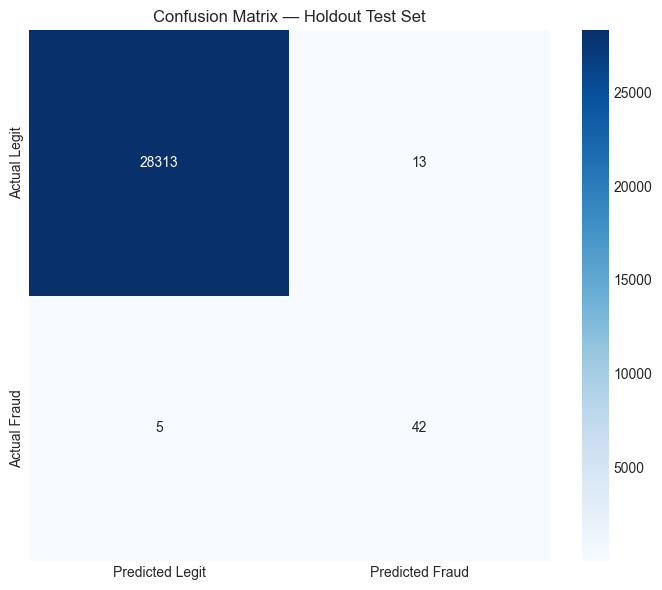

True Negatives (correct legit):   28,313
False Positives (false alarms):    13
False Negatives (missed fraud):    5  ← these are the costly ones
True Positives (caught fraud):     42

Fraud Recall (sensitivity): 0.8936
Fraud Precision:             0.7636


In [17]:
# ── Cell 12: Confusion Matrix ────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted Legit', 'Predicted Fraud'],
    yticklabels=['Actual Legit', 'Actual Fraud'],
    ax=ax
)
ax.set_title('Confusion Matrix — Holdout Test Set')
plt.tight_layout()
plt.savefig(MODELS_DIR / "confusion_matrix.png", dpi=120)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correct legit):   {tn:,}")
print(f"False Positives (false alarms):    {fp:,}")
print(f"False Negatives (missed fraud):    {fn:,}  ← these are the costly ones")
print(f"True Positives (caught fraud):     {tp:,}")
print(f"\nFraud Recall (sensitivity): {tp/(tp+fn):.4f}")
print(f"Fraud Precision:             {tp/(tp+fp):.4f}")

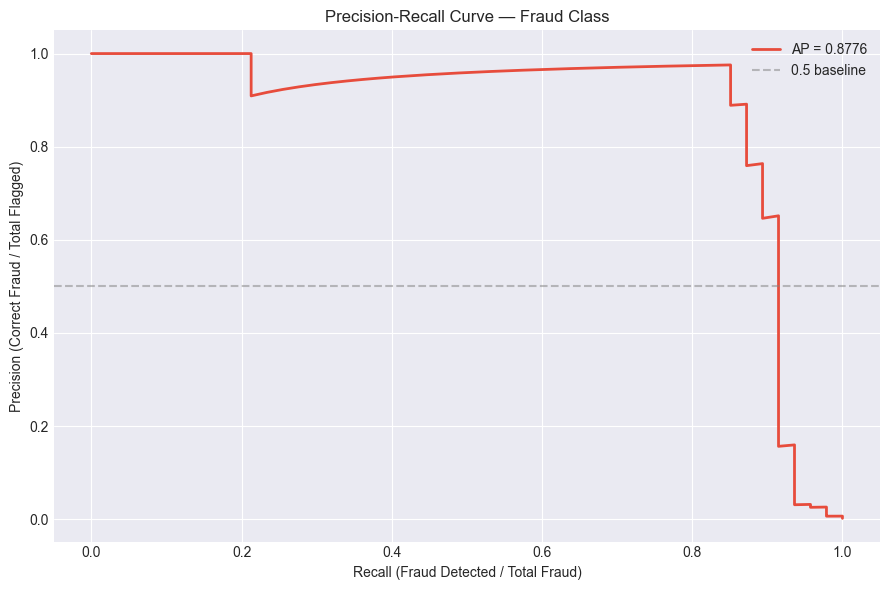

In [18]:
# ── Cell 13: Precision-Recall Curve ──────────────────────────────────────────
# WHY PR curve over ROC?
# ROC-AUC is optimistic on imbalanced datasets.
# PR curve focuses specifically on the minority class performance.

precision, recall, thresholds = precision_recall_curve(y_test, y_proba_test)
ap = average_precision_score(y_test, y_proba_test)

plt.figure(figsize=(9, 6))
plt.plot(recall, precision, color='#e74c3c', lw=2, label=f'AP = {ap:.4f}')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='0.5 baseline')
plt.xlabel('Recall (Fraud Detected / Total Fraud)')
plt.ylabel('Precision (Correct Fraud / Total Flagged)')
plt.title('Precision-Recall Curve — Fraud Class')
plt.legend()
plt.tight_layout()
plt.savefig(MODELS_DIR / "pr_curve.png", dpi=120)
plt.show()

In [19]:
# ── Cell 14: SHAP TreeExplainer ───────────────────────────────────────────────
# TreeExplainer uses the EXACT Shapley values algorithm optimised for trees.
# Shapley values come from cooperative game theory — each feature gets credit
# proportional to its MARGINAL CONTRIBUTION across all possible feature subsets.
#
# Interpretation:
#   SHAP value for V14 = -2.3 means:
#   "V14's value in this transaction pushed the fraud probability DOWN by 2.3 units"
#   Baseline (expected fraud prob) + all SHAP values = this transaction's fraud prob

print("Initialising SHAP TreeExplainer (this takes ~30s first time)...")
explainer = shap.TreeExplainer(best_model)

# Use first 500 test samples for visualisation (full set is slow for plots)
X_explain = X_test.iloc[:500]
shap_values = explainer.shap_values(X_explain)
print(f"SHAP values shape: {shap_values.shape}")

Initialising SHAP TreeExplainer (this takes ~30s first time)...
SHAP values shape: (500, 30)


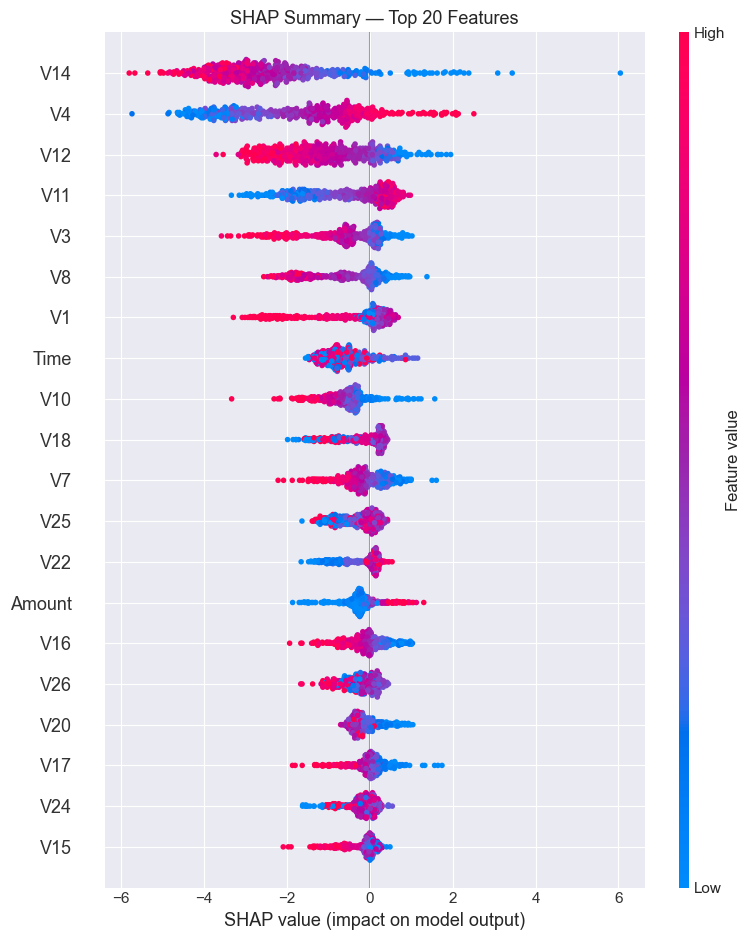

In [20]:
# ── Cell 15: SHAP Summary Plot ────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_explain,
    max_display=20,
    show=False,
    plot_type="dot"
)
plt.title("SHAP Summary — Top 20 Features", fontsize=13)
plt.tight_layout()
plt.savefig(MODELS_DIR / "shap_summary.png", dpi=120, bbox_inches='tight')
plt.show()

# ─── Reading the SHAP summary plot ───────────────────────────────────────────
# Y-axis: features sorted by mean |SHAP value| (most important at top)
# X-axis: SHAP value (+ = pushes toward fraud, - = pushes toward legitimate)
# Color:  feature value (red=high, blue=low)
# Each dot = one transaction
# V14, V10, V12 are typically the strongest fraud predictors in this dataset

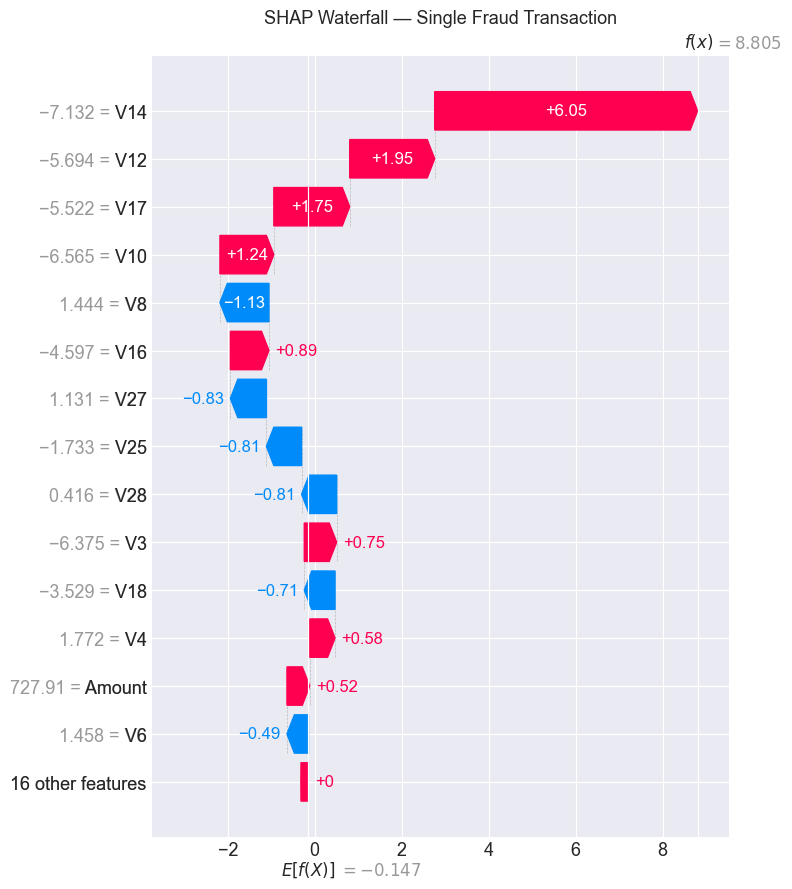

Transaction fraud probability: 0.9999


In [21]:
# ── Cell 16: SHAP Waterfall — Single Prediction ───────────────────────────────
# Pick a known fraud transaction to visualise
fraud_idx_in_test = y_test[y_test == 1].index[0]
fraud_pos = X_test.index.get_loc(fraud_idx_in_test)

single_shap = explainer(X_test.iloc[fraud_pos:fraud_pos+1])

plt.figure(figsize=(10, 6))
shap.waterfall_plot(single_shap[0], max_display=15, show=False)
plt.title("SHAP Waterfall — Single Fraud Transaction", fontsize=13)
plt.tight_layout()
plt.savefig(MODELS_DIR / "shap_waterfall.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"Transaction fraud probability: {best_model.predict_proba(X_test.iloc[fraud_pos:fraud_pos+1])[0,1]:.4f}")

In [22]:
# ── Cell 17: Save Artifacts ───────────────────────────────────────────────────
# model.pkl — the trained XGBoost model (joblib is faster than pickle for arrays)
model_path = MODELS_DIR / "fraud_model.pkl"
joblib.dump(best_model, model_path)
print(f"Saved model → {model_path}")

# feature_names.json — order matters for inference
feature_names = X_train.columns.tolist()
feat_path = MODELS_DIR / "feature_names.json"
with open(feat_path, 'w') as f:
    json.dump(feature_names, f, indent=2)
print(f"Saved features → {feat_path}  ({len(feature_names)} features)")

# Final summary
print("\n" + "="*50)
print("TRAINING SUMMARY")
print("="*50)
print(f"F1 Score (fraud):  {f1_score(y_test, y_pred_test):.4f}")
print(f"ROC-AUC:           {roc_auc_score(y_test, y_proba_test):.4f}")
print(f"Avg Precision:     {ap:.4f}")
print(f"Model path:        {model_path}")
print(f"Feature count:     {len(feature_names)}")
print("✅ Ready for FastAPI inference pipeline")

Saved model → ..\models\fraud_model.pkl
Saved features → ..\models\feature_names.json  (30 features)

TRAINING SUMMARY
F1 Score (fraud):  0.8235
ROC-AUC:           0.9920
Avg Precision:     0.8776
Model path:        ..\models\fraud_model.pkl
Feature count:     30
✅ Ready for FastAPI inference pipeline
